In [1]:
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [2]:
import torch
torch.__version__

'2.9.0+cpu'

In [3]:
!pip install gpytorch
!pip install botorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.8/287.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.3/176.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 28.6 MB/s eta 0:00:00


In [4]:
import torch
import math
import gpytorch
import botorch
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
from matplotlib import cm
from gpytorch.kernels import MaternKernel, ScaleKernel, RBFKernel, LinearKernel, PeriodicKernel
from botorch.acquisition import ExpectedImprovement, UpperConfidenceBound, PosteriorMean
from botorch.acquisition.monte_carlo import SampleReducingMCAcquisitionFunction
from botorch.optim import optimize_acqf
from botorch.sampling import SobolQMCNormalSampler
from gpytorch.constraints.constraints import Interval
from gpytorch.likelihoods.gaussian_likelihood import GaussianLikelihood
from gpytorch.constraints import GreaterThan
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.models.transforms.input import Normalize
from botorch.optim import optimize_acqf
from botorch.sampling.normal import SobolQMCNormalSampler
from botorch.utils.sampling import draw_sobol_samples
import botorch.sampling.get_sampler
from botorch.acquisition.monte_carlo import qExpectedImprovement  # NEW
from botorch.acquisition.objective import ConstrainedMCObjective   # NEW
plt.rcParams.update({'font.size':14})

# turn off warnings for clean output
import warnings
warnings.filterwarnings('ignore')

In [5]:
def save_plot(fig, plot_name, df, dpi=600):
    """
    Saves a Matplotlib figure as a PNG in the current working directory.
    The filename includes the plot name and the salt percentage (5 or 7.5).
    """
    salt = df["Salt_percentage"].iloc[0]
    salt_str = f"{salt}percent"

    filename = f"{plot_name}_{salt_str}.png"
    save_path = os.path.join(os.getcwd(), filename)

    fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {save_path}")

In [6]:
# Helper function that takes input data, kernel+likelihood specifications, and plotting options --> return trained model
def get_trained_GP(X, Y, kernel_type, noise_free=False, plot_1d=False, plot_bounds=None):
    """
    This function is used to train a GP model based on the type of kernel that you select.
    This function will be used in modules 1,2,and 3. Save this function for later
    If you delete this cell accidentally, let us know!

    -----------
    Arg:
    X: Features/ Input vector -- torch tensor
    Y: Mapping/ Target variable vector -- torch tensor
    kernel_type: 'RBF'/'Linear'/'Periodic'/'Matern05'/'Matern15'/'Matern25' select one -- str
    noise_free: True or False (are observations noise free?)
    plot_1d: True or False (should we plot or not?)
    plot_bounds: Tuple of lower and upper bounds (xL, xU)

    ----------
    returns:

    model: a GP model object in train mode -- gpytorch
    """

    # make sure input data is shaped properly (ntrain by ninputs)
    if X.ndim != 2:
        raise ValueError(f"X must be 2D (n_train x n_inputs), got shape {X.shape}")

    if X.shape[-1]!=2:
        raise ValueError(f"Expected exactly 2 inputs (Polymer_thickness_mm, PCL_ratio), got {X.shape[-1]}")


    # make sure training data has the right dimension
    if Y.ndim == 1:
        Y = Y.unsqueeze(-1)
    elif Y.ndim!=2 or Y.shape[-1]!=1:
        raise ValueError(f"Y must be of shape (n,) or (n,1), got {Y.shape}")



    # output scaling
    standardize = Standardize(m=Y.shape[-1])
    outcome_transform = standardize

    # select covariance module
    input_dim = X.shape[-1]

    if kernel_type == 'RBF':
        covar_module = ScaleKernel(RBFKernel(ard_num_dims=input_dim))
    elif kernel_type == 'Linear':
        covar_module = ScaleKernel(LinearKernel(ard_num_dims=input_dim))
    elif kernel_type == 'Periodic':
        covar_module = ScaleKernel(PeriodicKernel(ard_num_dims=input_dim))
    elif kernel_type == 'Matern05':
        covar_module = ScaleKernel(MaternKernel(nu=0.5, ard_num_dims=input_dim))
    elif kernel_type == 'Matern15':
        covar_module = ScaleKernel(MaternKernel(nu=1.5, ard_num_dims=input_dim))
    elif kernel_type == 'Matern25':
        covar_module = ScaleKernel(MaternKernel(nu=2.5, ard_num_dims=input_dim))
    else:
        raise ValueError(f"Unknown kernel_type '{kernel_type}'")

    # set the likelihood
    if noise_free:
      likelihood = GaussianLikelihood(noise_constraint=Interval(lower_bound=1e-5, upper_bound=1e-3))
    else:
      likelihood = GaussianLikelihood(noise_constraint=gpytorch.constraints.GreaterThan(1e-3), #consider 1e-2
                                      noise_prior=gpytorch.priors.NormalPrior(0, 1))

    # define the model
    model = SingleTaskGP(
        train_X=X,
        train_Y=Y,
        covar_module=covar_module,
        likelihood=likelihood,
        outcome_transform=outcome_transform
    )

    # call the training procedure
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)

    # put in eval mode
    model.eval()

    # plot if specified
    if plot_1d:
      if input_dim == 1:
        if plot_bounds is None:
            print("Plot bounds not specified!")
        else:
          x_list = torch.linspace(plot_bounds[0], plot_bounds[1], 101)
          preds = model.posterior(x_list.unsqueeze(-1))
          mean = preds.mean.squeeze()
          var = preds.variance.squeeze()
          lcb = mean - 2*torch.sqrt(var)
          lcb = np.maximum(lcb, 0)
          ucb = mean + 2*torch.sqrt(var)


          plt.figure(figsize=(12,10))
          plt.plot(x_list, mean.detach().numpy())
          plt.fill_between(
              x_list,
              lcb.detach().numpy(),
              ucb.detach().numpy(),
              alpha=0.2
          )
          plt.scatter(
              X.detach().numpy(),
              Y.detach().numpy(),
              color ='red',
              marker ='*'
          )
          plt.xlabel('input')
          plt.ylabel('target')
      else:
        print("Too many input dimensions to plot!")

    # return the trained model
    return model

In [7]:
def run_GP_and_Plot(df):
    # -----------------------------
    # 1. Fetching input and output
    # -----------------------------
    X_raw = torch.tensor(
        df[["Polymer_thickness_mm", "PCL_ratio"]].to_numpy(),
        dtype=torch.double,
    )
    Y_raw = torch.tensor(
        df["t_cross_days"].to_numpy(),
        dtype=torch.double,
    ).unsqueeze(-1)   # (n,1)

    # -----------------------------
    # 2. BO domain (outer bounds)
    # -----------------------------
    thickness_min = 0.001
    thickness_max = 0.09
    ratio_min = 0.01
    ratio_max = 1.0
    x_min = torch.tensor([thickness_min, ratio_min], dtype=torch.double)
    x_max = torch.tensor([thickness_max, ratio_max], dtype=torch.double)

    # scale inputs to [0,1]^3
    X_scaled = (X_raw - x_min) / (x_max - x_min)

    # -----------------------------
    # 3. Train GP on scaled X, negative Y
    # -----------------------------
    model = get_trained_GP(
        X_scaled,
        Y_raw,
        kernel_type="RBF",
        noise_free=False,
        plot_1d=False,
    )

    # make sure model is double
    model = model.to(torch.double)

    # -----------------------------
    # 4) Constrained qEI in ORIGINAL UNITS (robust to Standardize & sampler API)
    # -----------------------------
    from botorch.acquisition.objective import ConstrainedMCObjective
    from botorch.acquisition.monte_carlo import qExpectedImprovement
    from botorch.sampling.normal import SobolQMCNormalSampler
    from botorch.models.transforms.outcome import Standardize

    # Build a sampler (handle older/newer BoTorch APIs)
    try:
        sampler = SobolQMCNormalSampler(sample_shape=torch.Size([1024]))
    except TypeError:
        sampler = SobolQMCNormalSampler(num_samples=1024)

    # Pull Standardize stats if present; otherwise, identity (operate already in original units)
    stdize = getattr(model, "outcome_transform", None)
    if isinstance(stdize, Standardize) and hasattr(stdize, "means") and hasattr(stdize, "stds"):
      # shapes are [1, m]; for single-output m=1
        m = stdize.means.detach().to(dtype=torch.double)
        s = stdize.stds.detach().to(dtype=torch.double)

        def to_original(y_samples):
            # y_samples shape: [..., q, 1]; broadcast m,s over samples
            return y_samples * s + m
    else:
        # Model posterior is already in original units (or no transform attached)
        def to_original(y_samples):
            return y_samples

    # Objective: maximize t_cross_days in original units
    def obj(samples, X=None):
        y = to_original(samples)      # -> original units (days)
        return y.squeeze(-1)          # shape [..., q]

    # Constraint: feasible iff t_cross_days >= 0 (in original units)
    def constraint(samples, X=None):
        y = - to_original(samples) # need minus sign because BoTorch default constraint is c(x)<=0
        return y.squeeze(-1)          # >= 0 is feasible

    constrained_obj = ConstrainedMCObjective(
        objective=obj,
        constraints=[constraint],
        infeasible_cost=torch.tensor(-1e-3, dtype=torch.double),  # small negative to keep gradient signal
    )

    # best_f must be in the same units as obj() -> original units (days)
    feas_mask = (Y_raw.squeeze(-1) >= 0)
    best_f = Y_raw[feas_mask].max().item() if feas_mask.any() else 0.0

    ei = qExpectedImprovement(
        model=model,
        best_f=best_f,
        sampler=sampler,
        objective=constrained_obj,
    )



    # -----------------------------
    # 5. Optimize EI in scaled space to get next point
    # -----------------------------
    bounds_scaled = torch.stack(
        [
            torch.zeros(2, dtype=torch.double), #I changed this from 3 to 2
            torch.ones(2, dtype=torch.double),  #I changed this from 3 to 2
        ]
    )

    candidate, acq_value = optimize_acqf(
        acq_function=ei,
        bounds=bounds_scaled,
        q=1, # number of next input values to determine
        num_restarts=20,
        raw_samples=512,
    )

    x_next_scaled = candidate[0]              # shape (q, 2) where 2 is the number of input dimensions
    x_next = x_next_scaled * (x_max - x_min) + x_min   # back to physical space

    Polymer_thickness_mm_next = float(x_next[0].item())
    PCL_ratio_next    = float(x_next[1].item())
    ei_next     = float(acq_value.item())

    print("Suggested next input (unscaled):")
    print(f"  Polymer_thickness_mm = {Polymer_thickness_mm_next:.6g}")
    print(f"  PCL_ratio    = {PCL_ratio_next:.6g}")
    print(f"EI at this point = {ei_next:.6g}")

    # Scale new point to [0,1]^3
    x_new_scaled = (x_next - x_min) / (x_max - x_min)

    with torch.no_grad():
        post = model.posterior(x_new_scaled.unsqueeze(0))  # shape (1,3)
        pred_mean = post.mean.item()   # model predicts time in days to cross threshold
        std = post.variance.sqrt().item()

    print(f"\nGP-predicted time in days to cross the threshold at suggested point: {pred_mean:.6f}")
    print(f"GP uncertainty (std): {std:.6f}")

    bounds_dict = {
    "Polymer_thickness_mm": (thickness_min, thickness_max),
    "PCL_ratio": (ratio_min, ratio_max),
    }

    plot_gp_plus_ei_slice(
        "Polymer_thickness_mm",
        Polymer_thickness_mm_next, PCL_ratio_next,
        model, ei, bounds_dict, df,
        x_min, x_max,
    )

    plot_gp_plus_ei_slice(
        "PCL_ratio",
        Polymer_thickness_mm_next, PCL_ratio_next,
        model, ei, bounds_dict, df,
        x_min, x_max,
    )

    #Polymer_thickness_mm_star = Polymer_thickness_mm_next
    #PCL_ratio_star    = PCL_ratio_next

    #plot_ei_slice("Polymer_thickness_mm", Polymer_thickness_mm_star, PCL_ratio_star, bounds_dict)
    #plot_ei_slice("PCL_ratio",    Polymer_thickness_mm_star, PCL_ratio_star, bounds_dict)

    plot_gp_plus_ei_2d3d(model, ei, bounds_dict, df, x_min, x_max,
                       n_grid=100)


In [8]:
def plot_gp_plus_ei_slice(
    dim_name, Polymer_thickness_mm_val, PCL_ratio_val,
    model, ei_acq, bounds_dict, df,
    x_min, x_max,
):
    """
    dim_name : "Polymer_thickness_mm", "PCL_ratio"
    Polymer_thickness_mm_val, PCL_ratio_val: slice location in *physical* space
    model : GP trained on *scaled* inputs and t_cross_days
    ei_acq : ExpectedImprovement object
    bounds_dict : {"Polymer_thickness_mm": (Lmin,Lmax), "PCL_ratio_val":(...)} in physical space
    df : dataframe with columns ["Polymer_thickness_mm","PCL_ratio","t_cross_days"]
    x_min, x_max : tensors used for scaling (physical space)
    """

    # -----------------------
    # 1) Build physical grid for the slice
    # -----------------------
    lower, upper = bounds_dict[dim_name]

    grid_phys = torch.linspace(lower, upper, 200, dtype=torch.double)

    if dim_name == "Polymer_thickness_mm":
        Polymer_thickness_mm_phys = grid_phys
        PCL_ratio_phys = torch.full_like(grid_phys, PCL_ratio_val, dtype=torch.double)
        x_label = "Polymer_thickness_mm"

    elif dim_name == "PCL_ratio":
        Polymer_thickness_mm_phys = torch.full_like(grid_phys, Polymer_thickness_mm_val, dtype=torch.double)
        PCL_ratio_phys = grid_phys
        x_label = "PCL_ratio"

    Xtest_phys = torch.stack([Polymer_thickness_mm_phys, PCL_ratio_phys], dim=1)   # (N,2)

    # -----------------------
    # 2) Scale Xtest to [0,1]^3 for the GP
    # -----------------------
    Xtest_scaled = (Xtest_phys - x_min) / (x_max - x_min)
    Xtest_scaled = Xtest_scaled.to(torch.double)

    # -----------------------
    # 3) GP posterior (on t_cross_days)
    # -----------------------
    with torch.no_grad():
        post = model.posterior(Xtest_scaled)
        mean = post.mean.squeeze(-1).cpu().numpy()
        std = post.variance.sqrt().squeeze(-1).cpu().numpy()
        print("STD range on this slice:", std.min(), std.max())

    # Convert back to t_cross_days
    lcb = mean - 2.0 * std
    lcb = np.maximum(lcb, 0)
    ucb = mean + 2.0 * std

    # -----------------------
    # 4) EI values on this slice (use scaled X)
    # -----------------------
    with torch.no_grad():
        ei_vals = ei_acq(Xtest_scaled.unsqueeze(1)).squeeze(-1).cpu().numpy()

    # -----------------------
    # 5) Observed points projected to this axis
    # -----------------------
    dim_col = {"Polymer_thickness_mm": "Polymer_thickness_mm", "PCL_ratio": "PCL_ratio"}[dim_name]
    x_obs = df[dim_col].to_numpy()
    y_obs = df["t_cross_days"].to_numpy()

    # -----------------------
    # 6) Plot
    # -----------------------
    x_grid_np = grid_phys.cpu().numpy()

    fig, ax1 = plt.subplots(figsize=(9, 5))

    # GP CI band
    ax1.fill_between(x_grid_np, lcb, ucb, color="lightblue", alpha=0.3, label="95% CI")

    # GP mean
    ax1.plot(x_grid_np, mean, color="blue", linewidth=2, label="GP mean")

    # Observed data
    ax1.scatter(x_obs, y_obs, color="red", marker="x", s=50, label="Observed")

    ax1.set_xlabel(x_label)
    ax1.set_ylabel("t_cross_days")
    ax1.grid(True)

    # EI on twin axis
    ax2 = ax1.twinx()
    ax2.plot(x_grid_np, ei_vals, color="orange", linestyle="--", linewidth=2, label="EI")
    ax2.set_ylabel("EI", color="orange")

    # # Pad the upper limit of ax2 to avoid clipping
    # ei_max = ei_vals.max()
    # ax2.set_ylim(top=ei_max * 1.2)  # 20% padding

    # Legends
    if dim_name == "Polymer_thickness_mm":
        ax1.legend(loc="upper center")
    else:
        ax1.legend(loc="center")
    ax2.legend(loc="upper right")

    plt.title(f"GP Posterior + EI Slice over {x_label}")

    if dim_name == "Polymer_thickness_mm":
      # --- 1) Let Matplotlib autoscale ---
      fig.canvas.draw()

      # Autoscaled limits
      y1_min, y1_max = ax1.get_ylim()
      y2_min, y2_max = ax2.get_ylim()

      # --- 2) Align the zero positions ---
      pos1 = (0 - y1_min) / (y1_max - y1_min)
      span2 = y2_max - y2_min

      new_y2_min = 0 - pos1 * span2
      new_y2_max = new_y2_min + span2

      ax2.set_ylim(new_y2_min, new_y2_max)

      # --- 3) Ensure EI max is still visible ---
      ei_max = ei_vals.max()

      # If EI max is above the new upper limit, extend it
      if ei_max > new_y2_max:
          ax2.set_ylim(new_y2_min, ei_max * 1.05)   # small 5% padding

    plt.tight_layout()

    #if df[["phenotype"]].values[0][0]=="network":
      #  save_path=os.path.join(net_plt_path, f"GP_EI_over_{dim_name}.png")
    #else:
      #  save_path=os.path.join(sph_plt_path, f"GP_EI_over_{dim_name}.png")
    #plt.savefig(save_path, dpi=300, bbox_inches='tight')

    #print(f"Plot saved successfully at:\n{save_path}")

    save_plot(fig, f"GP_EI_slice_{dim_name}", df)
    plt.show()


In [9]:
def plot_ei_slice(dim, Polymer_thickness_mm_val, PCL_ratio_val, bounds_dict, n=200):
    #bounds_dict : {"Polymer_thickness_mm": (Lmin,Lmax), "PCL_ratio_val":(...)} in physical space

    th_min, th_max = bounds_dict["Polymer_thickness_mm"]
    pcl_min, pcl_max = bounds_dict["PCL_ratio"]

    # Build a grid along the selected dimension
    if dim == "Polymer_thickness_mm":
        grid = torch.linspace(th_min, th_max, n)
        Polymer_thickness_mm = grid
        PCL_ratio = torch.full_like(grid, PCL_ratio_val)
        xlabel = "Polymer_thickness_mm"

    elif dim == "PCL_ratio":
        grid = torch.linspace(pcl_min, pcl_max, n)
        Polymer_thickness_mm = torch.full_like(grid, Polymer_thickness_mm_val)
        PCL_ratio = grid
        xlabel = "PCL_ratio"

    # Scale inputs
    Xtest = torch.stack([Polymer_thickness_mm, PCL_ratio], dim=1).double()
    Xtest_scaled = (Xtest - x_min) / (x_max - x_min)

    from botorch.acquisition import ExpectedImprovement
    best_f = Y_raw.max().item()
    ei = ExpectedImprovement(model=model, best_f=best_f, maximize=True)

    with torch.no_grad():
        ei_vals = ei(Xtest_scaled.unsqueeze(1)).squeeze().numpy()

    plt.figure(figsize=(7,4))
    plt.plot(grid.numpy(), ei_vals, lw=2)
    plt.title(f"EI slice over {xlabel}")
    plt.xlabel(xlabel)
    plt.ylabel("EI")
    plt.grid(True)

    #if df[["phenotype"]].values[0][0]=="network":
       # save_path=os.path.join(net_plt_path, f"EI_slice_over_{dim}.png")
    #else:
      #  save_path=os.path.join(sph_plt_path, f"EI_slice_over_{dim}.png")
    #plt.savefig(save_path, dpi=300, bbox_inches='tight')

   # print(f"Plot saved successfully at:\n{save_path}")
    save_plot(plt.gcf(), f"EI_slice_{dim}", df)
    plt.show()


In [10]:
def plot_gp_plus_ei_2d3d(model, ei_acq, bounds_dict, df, x_min, x_max,
                       n_grid=100):
    """
    model: GP trained on scaled inputs, predicting t_cross_days
    ei_acq: ExpectedImprovement object
    bounds_dict: {"Polymer_thickness_mm": (Lmin,Lmax), "PCL_ratio": (Lmin,Lmax)}
    df: dataframe with columns ["Polymer_thickness_mm","PCL_ratio","t_cross_days"]
    x_min, x_max: tensors used for scaling
    """

    # -----------------------
    # 1) Build 2D physical grid
    # -----------------------
    th_min, th_max = bounds_dict["Polymer_thickness_mm"]
    pcl_min, pcl_max = bounds_dict["PCL_ratio"]

    th_grid = torch.linspace(th_min, th_max, n_grid, dtype=torch.double)
    pcl_grid = torch.linspace(pcl_min, pcl_max, n_grid, dtype=torch.double)

    TH, PCL = torch.meshgrid(th_grid, pcl_grid, indexing="ij")  # (n,n)

    X_phys = torch.stack([TH.reshape(-1), PCL.reshape(-1)], dim=1)  # (n^2, 2)

    # -----------------------
    # 2) Scale to GP input space
    # -----------------------
    X_scaled = (X_phys - x_min) / (x_max - x_min)
    X_scaled = X_scaled.to(torch.double)

    with torch.no_grad():
        vals = ei_acq(X_scaled.unsqueeze(1))
        print("EI (min, max) =", vals.min().item(), vals.max().item())

    # -----------------------
    # 3) GP posterior
    # -----------------------
    with torch.no_grad():
        post = model.posterior(X_scaled)
        mean = post.mean.view(-1).cpu().numpy()
        std = post.variance.sqrt().view(-1).cpu().numpy()

    # -----------------------
    # 4) EI values
    # -----------------------
    with torch.no_grad():
        ei_vals = ei_acq(X_scaled.unsqueeze(1)).view(-1).cpu().numpy()

    # -----------------------
    # 5) Reshape for plotting
    # -----------------------
    mean_2d = mean.reshape(n_grid, n_grid)
    std_2d = std.reshape(n_grid, n_grid)
    ei_2d = ei_vals.reshape(n_grid, n_grid)

    # -----------------------
    # -----------------------
    # 6) Plot GP posterior mean
    # -----------------------
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    im0 = ax[0].imshow(
        mean_2d,
        origin="lower",
        extent=[pcl_min, pcl_max, th_min, th_max],
        aspect="auto",
        cmap="viridis",
    )
    ax[0].set_title("GP Posterior Mean (t_cross_days)")
    ax[0].set_xlabel("PCL_ratio")
    ax[0].set_ylabel("Polymer_thickness_mm")
    fig.colorbar(im0, ax=ax[0])

    # ----------------------------------------------------
    # Plot all observed points (red)
    # ----------------------------------------------------
    ax[0].scatter(
        df["PCL_ratio"],
        df["Polymer_thickness_mm"],
        c="red",
        s=40,
        marker="x",
        label="LHS"
    )

    # ----------------------------------------------------
    # NEW LOGIC: highlight based on t_cross_days
    # ----------------------------------------------------
    dataset_max = df["dataset"].max()

    # A palette with enough distinct colors
    color_list = ["cyan", "magenta", "lime", "orange","black", "brown", "silver", "gold", "green"]

    # We will collect legend handles manually
    legend_handles = []

    if dataset_max == 1:
        # Only one dataset → highlight the single highest t_cross_days
        idx = df["t_cross_days"].idxmax()
        df_high = df.loc[[idx]]

        h = ax[0].scatter(
            df_high["PCL_ratio"],
            df_high["Polymer_thickness_mm"],
            c="cyan",
            s=90,
            marker="x",
            linewidths=2.5,
            label="LHS best"
        )
        legend_handles.append(h)

    else:
        # Multiple datasets → highlight the max t_cross_days within each dataset
        for ds_id in range(1, dataset_max + 1):
            df_sub = df[df["dataset"] == ds_id]
            if len(df_sub) == 0:
                continue

            idx = df_sub["t_cross_days"].idxmax()
            df_high = df.loc[[idx]]

            color = color_list[(ds_id - 1) % len(color_list)]

            # Labeling rule:
            if ds_id == 1:
                label = "LHS best"
            else:
                label = f"GP design{ds_id - 1}"

            h = ax[0].scatter(
                df_high["PCL_ratio"],
                df_high["Polymer_thickness_mm"],
                c=color,
                s=90,
                marker="x",
                linewidths=2.5,
                label=label
            )
            legend_handles.append(h)

    # ----------------------------------------------------
    # Final legend: Observed + highlight labels
    # ----------------------------------------------------
    # Legend anchored to the subplot, but placed higher
    ax[0].legend(
        handles=[ax[0].collections[0]] + legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.30),   # move legend higher above the axes
        ncol=3,
        frameon=True
    )


    # -----------------------
    # 7) Plot EI
    # -----------------------
    im1 = ax[1].imshow(ei_2d, origin="lower",
                       extent=[pcl_min, pcl_max, th_min, th_max],
                       aspect="auto", cmap="inferno")
    ax[1].set_title("Expected Improvement")
    ax[1].set_xlabel("PCL_ratio")
    ax[1].set_ylabel("Polymer_thickness_mm")
    fig.colorbar(im1, ax=ax[1])

    # Overlay observed points
    ax[1].scatter(df["PCL_ratio"], df["Polymer_thickness_mm"],
                  c="cyan", s=40, marker="x")

    plt.tight_layout()

    if df["Salt_percentage"].iloc[0] == 5:
      plt.subplots_adjust(top=0.88)   # reserve vertical space for the legend
    else:
      plt.subplots_adjust(top=1.05)   # reserve vertical space for the legend
    plt.show()
    save_plot(fig, "GP_2D_mean_EI", df)

    """
    TH, PCL: meshgrid tensors (n,n)
    mean_2d, std_2d: numpy arrays (n,n)
    """

    # 95% confidence interval surfaces
    lcb_2d = mean_2d - 2 * std_2d
    lcb_2d = np.maximum(lcb_2d, 0)
    ucb_2d = mean_2d + 2 * std_2d



    # Convert to numpy for plotting
    TH_np = TH.cpu().numpy()
    PCL_np = PCL.cpu().numpy()

    fig = plt.figure(figsize=(12, 8), constrained_layout=True)
    ax = fig.add_subplot(111, projection="3d")

    # Mean surface
    ax.plot_surface(PCL_np, TH_np, mean_2d,
                    cmap="viridis", alpha=0.9, linewidth=0, antialiased=True)

    # Lower CI surface
    ax.plot_surface(PCL_np, TH_np, lcb_2d,
                    color="blue", alpha=0.25, linewidth=0)

    # Upper CI surface
    ax.plot_surface(PCL_np, TH_np, ucb_2d,
                    color="blue", alpha=0.25, linewidth=0)

    ax.set_xlabel("PCL_ratio")
    ax.set_ylabel("Polymer_thickness_mm")
    ax.set_zlabel("t_cross_days", labelpad=1.3)
    ax.set_title("3D GP Posterior with 95% Confidence Surfaces")

    plt.show()
    save_plot(fig, "GP_3D_posterior", df)

    from mpl_toolkits.mplot3d import Axes3D

    """
    TH, PCL: meshgrid tensors (n,n)
    ei_2d: numpy array (n,n) of EI values
    """

    TH_np = TH.cpu().numpy()
    PCL_np = PCL.cpu().numpy()

    fig = plt.figure(figsize=(12, 8), constrained_layout=True)
    ax = fig.add_subplot(111, projection="3d")

    # EI surface
    surf = ax.plot_surface(PCL_np, TH_np, ei_2d,
                          cmap="inferno", linewidth=0,
                          antialiased=True, alpha=0.9)

    # Axis labels with padding and font size
    ax.set_xlabel("PCL_ratio", labelpad=10, fontsize=12)
    ax.set_ylabel("Polymer_thickness_mm", labelpad=10, fontsize=12)
    ax.set_zlabel("Expected Improvement", labelpad=15, fontsize=12)  # Increased labelpad

    # Title
    ax.set_title("3D Expected Improvement Surface", pad=20)

    # Colorbar
    fig.colorbar(surf, ax=ax, shrink=0.6)

    plt.show()
    save_plot(fig, "GP_3D_EI_surface", df)

In [11]:
base_path = os.path.join(os.getcwd())# replace it with path relative your data location
df_all=pd.read_csv(os.path.join(base_path, "DataSheetForBO.csv"))
df_all.head()
df_5 = df_all.loc[df_all["Salt_percentage"] == 5.0]
print(df_5.head())
print(df_5.shape[0])


   Salt_percentage  R_core_mm  Polymer_thickness_mm  PCL_ratio  Chi_ratio  \
0              5.0     0.1665                0.0635     0.0500     0.9500   
1              5.0     0.2114                0.0186     0.7064     0.2936   
2              5.0     0.1594                0.0706     0.8557     0.1443   
3              5.0     0.1975                0.0325     0.5760     0.4240   
4              5.0     0.2150                0.0150     0.9500     0.0500   

          a         b         c         d  t_cross_days  dataset  
0  0.412983 -0.001172 -0.005274 -0.005258      0.000000        1  
1  1.590128 -0.002963 -0.016275 -0.028405    192.038401        1  
2  0.408224 -0.001218 -0.001515 -0.016210      0.000000        1  
3  0.916568 -0.001859 -0.009994 -0.011066      4.137023        1  
4  2.066897 -0.003750 -0.019521 -0.048441    221.699739        1  
17


Suggested next input (unscaled):
  Polymer_thickness_mm = 0.0139756
  PCL_ratio    = 0.01
EI at this point = 0.0754464

GP-predicted time in days to cross the threshold at suggested point: 220.969848
GP uncertainty (std): 1.608748
STD range on this slice: 1.6085433852315738 33.98679863127935
Saved: /content/GP_EI_slice_Polymer_thickness_mm_5.0percent.png


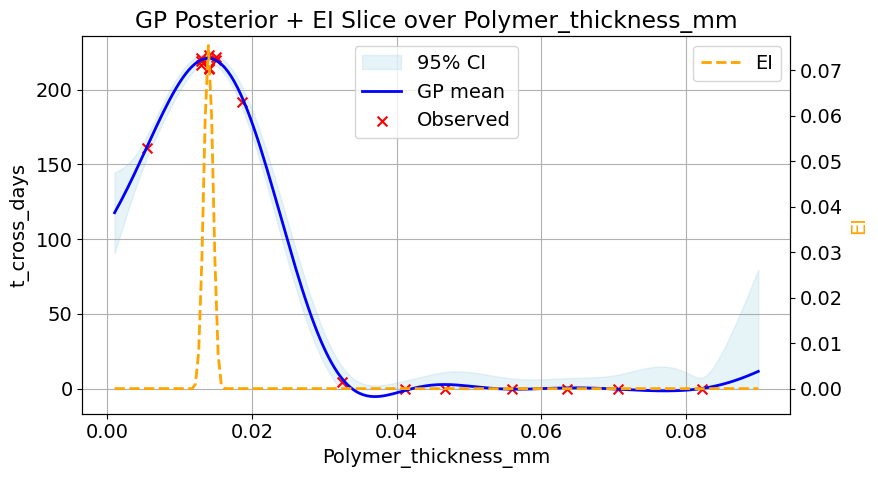

STD range on this slice: 1.1960219545986575 1.7083143620091925
Saved: /content/GP_EI_slice_PCL_ratio_5.0percent.png


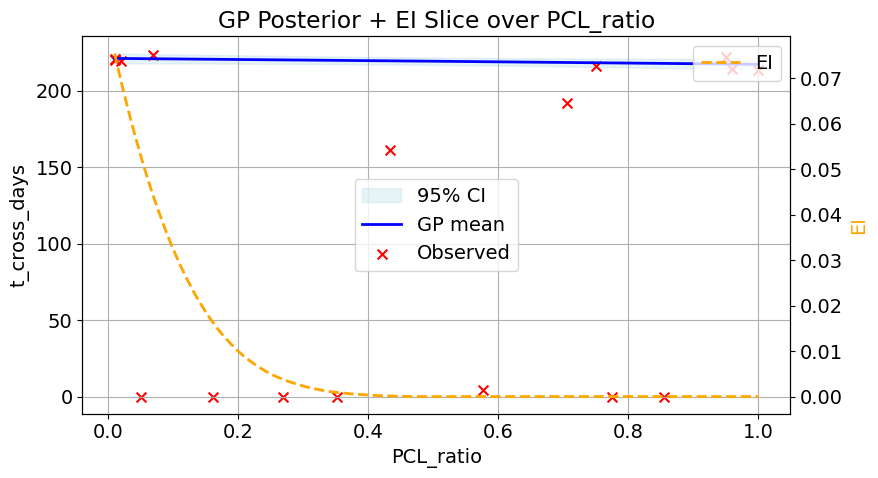

EI (min, max) = 0.0 0.06307581693893177


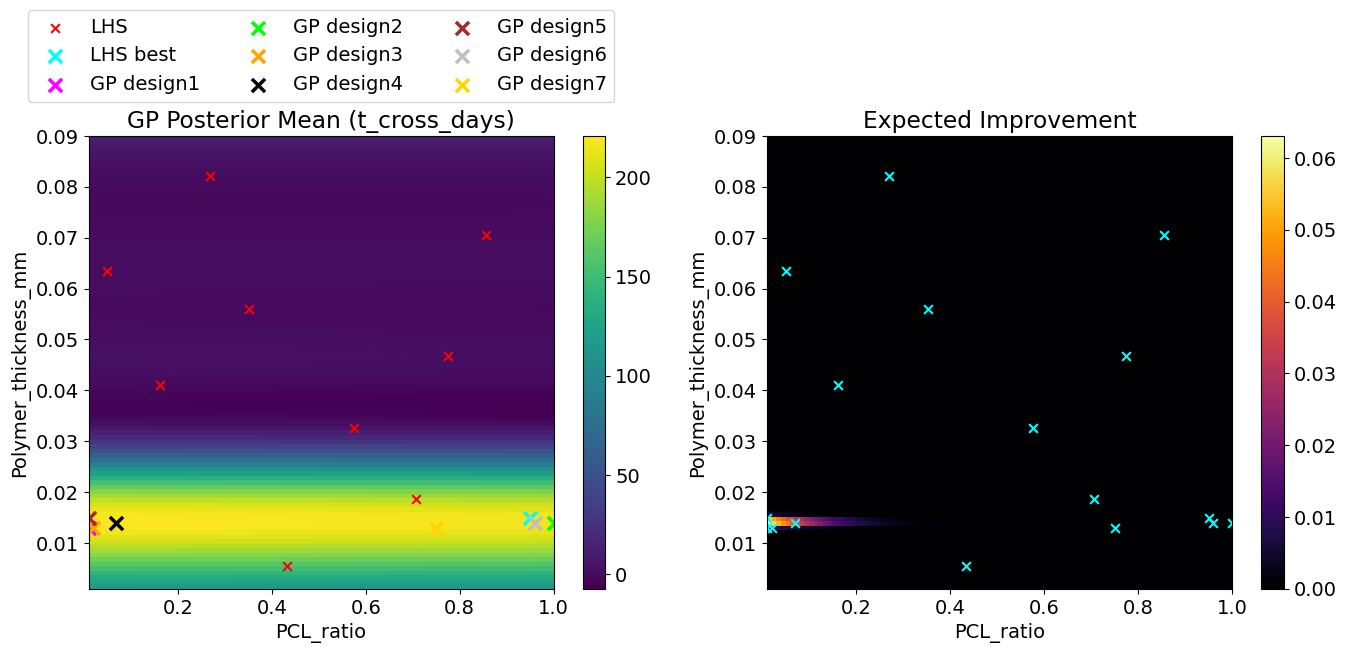

Saved: /content/GP_2D_mean_EI_5.0percent.png


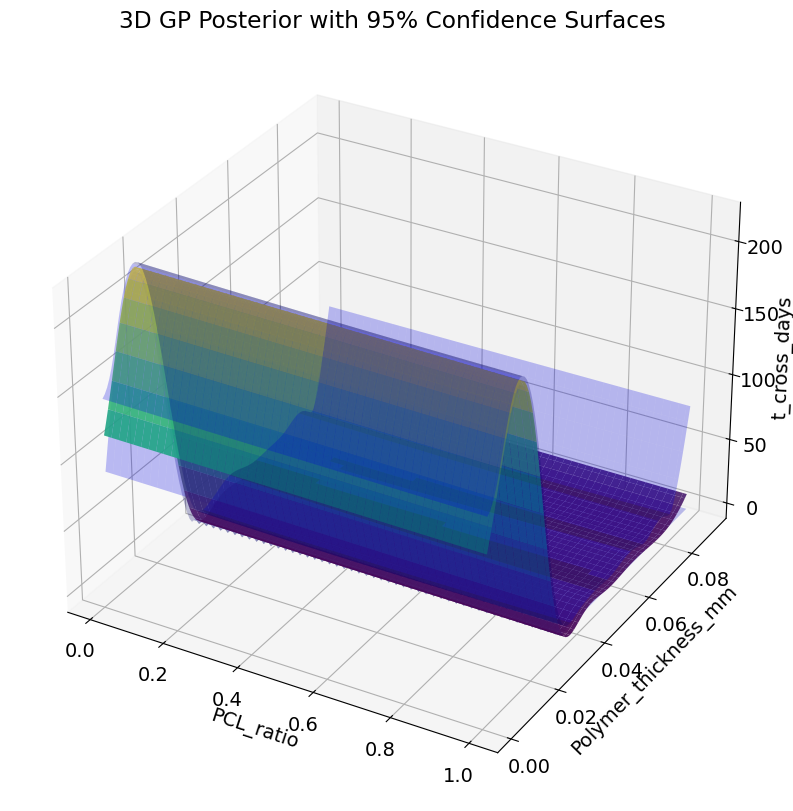

Saved: /content/GP_3D_posterior_5.0percent.png


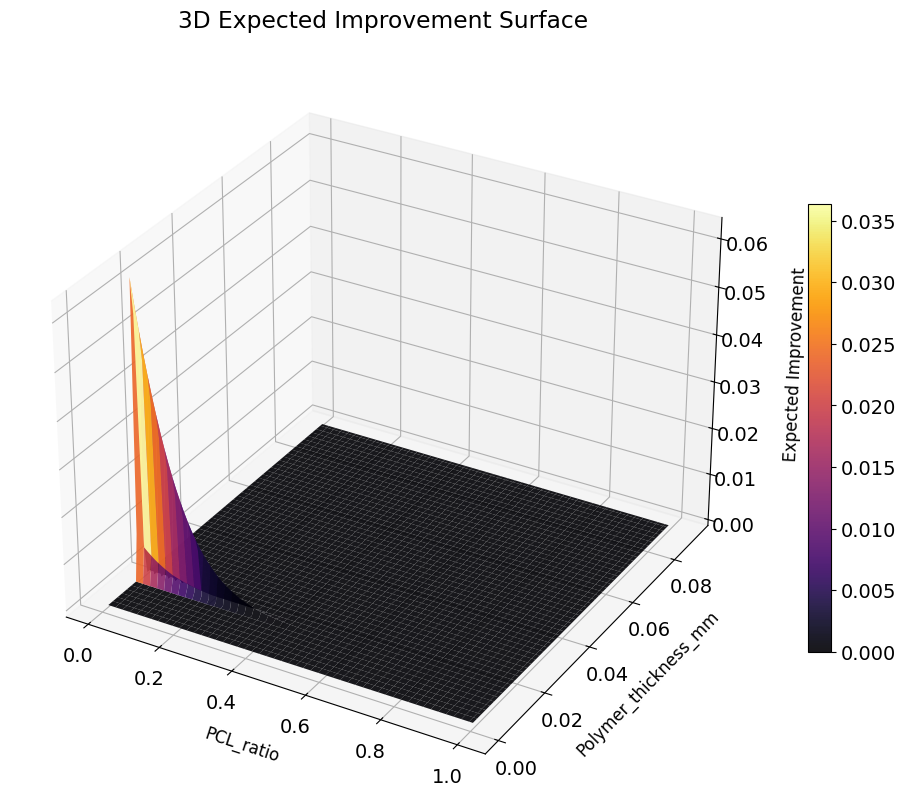

Saved: /content/GP_3D_EI_surface_5.0percent.png


In [12]:
df = df_5
run_GP_and_Plot(df)

In [13]:
df_7pt5 = df_all.loc[df_all["Salt_percentage"] == 7.5]
print(df_7pt5.head())
print(df_7pt5.shape[0])


    Salt_percentage  R_core_mm  Polymer_thickness_mm  PCL_ratio  Chi_ratio  \
10              7.5     0.1665                0.0635     0.0565     0.9435   
11              7.5     0.2114                0.0186     0.7064     0.2936   
12              7.5     0.1594                0.0706     0.8557     0.1443   
13              7.5     0.1975                0.0325     0.5760     0.4240   
14              7.5     0.2150                0.0150     0.9500     0.0500   

           a         b         c         d  t_cross_days  dataset  
10  0.242147 -0.000779  0.000000 -0.000779      0.000000        1  
11  1.566264 -0.003511 -0.027086 -0.023171    157.601684        1  
12  0.558047 -0.001861 -0.004878 -0.015903      0.000000        1  
13 -0.001413  0.005682  0.814502 -0.001710      0.000000        1  
14  2.415579 -0.007702 -0.088515 -0.070965    128.190604        1  
20


Suggested next input (unscaled):
  Polymer_thickness_mm = 0.00857455
  PCL_ratio    = 0.01
EI at this point = 1.57058

GP-predicted time in days to cross the threshold at suggested point: 190.789652
GP uncertainty (std): 3.497841
STD range on this slice: 2.585903486860363 56.974560853945306
Saved: /content/GP_EI_slice_Polymer_thickness_mm_7.5percent.png


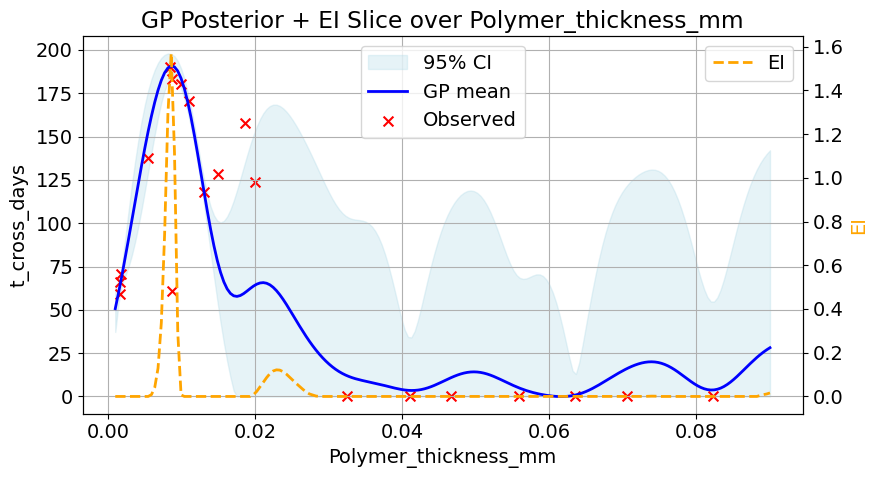

STD range on this slice: 2.4549790344396345 13.413635201987804
Saved: /content/GP_EI_slice_PCL_ratio_7.5percent.png


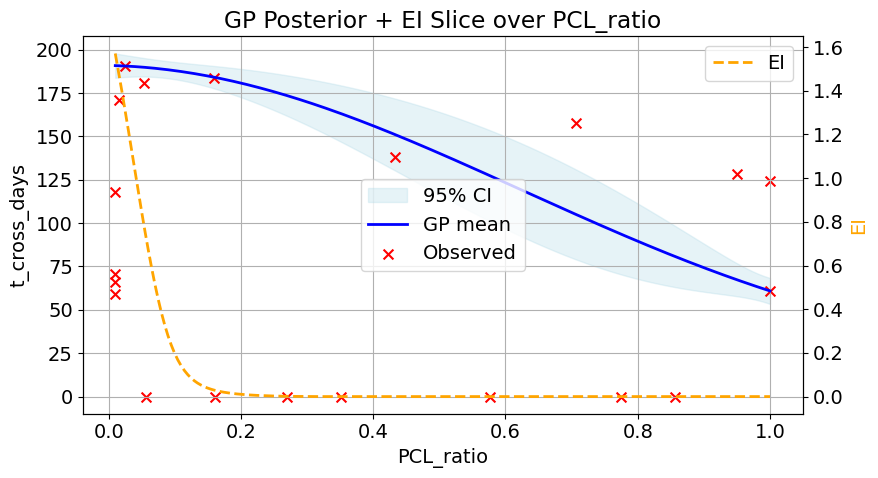

EI (min, max) = 0.0 1.3310331050114599


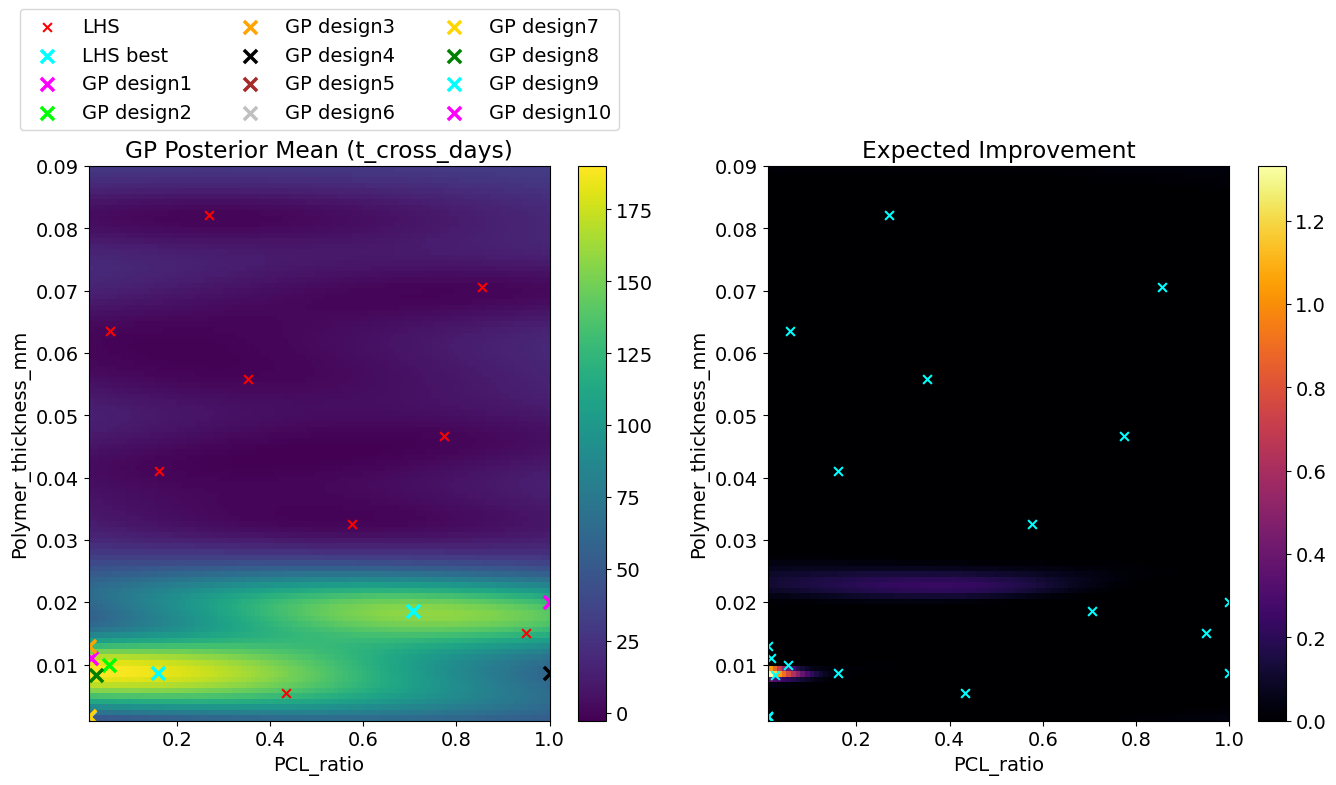

Saved: /content/GP_2D_mean_EI_7.5percent.png


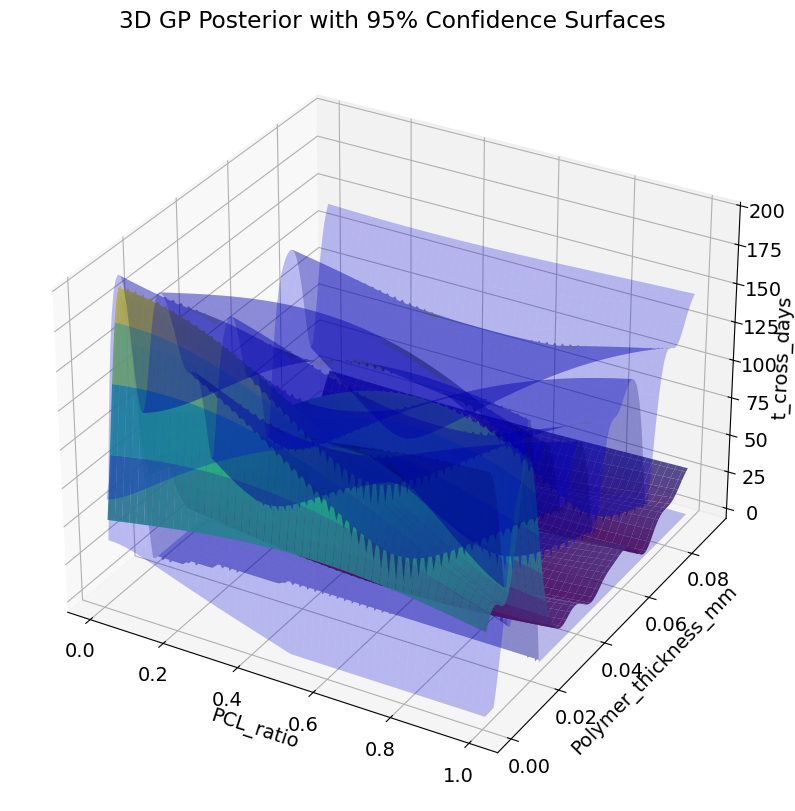

Saved: /content/GP_3D_posterior_7.5percent.png


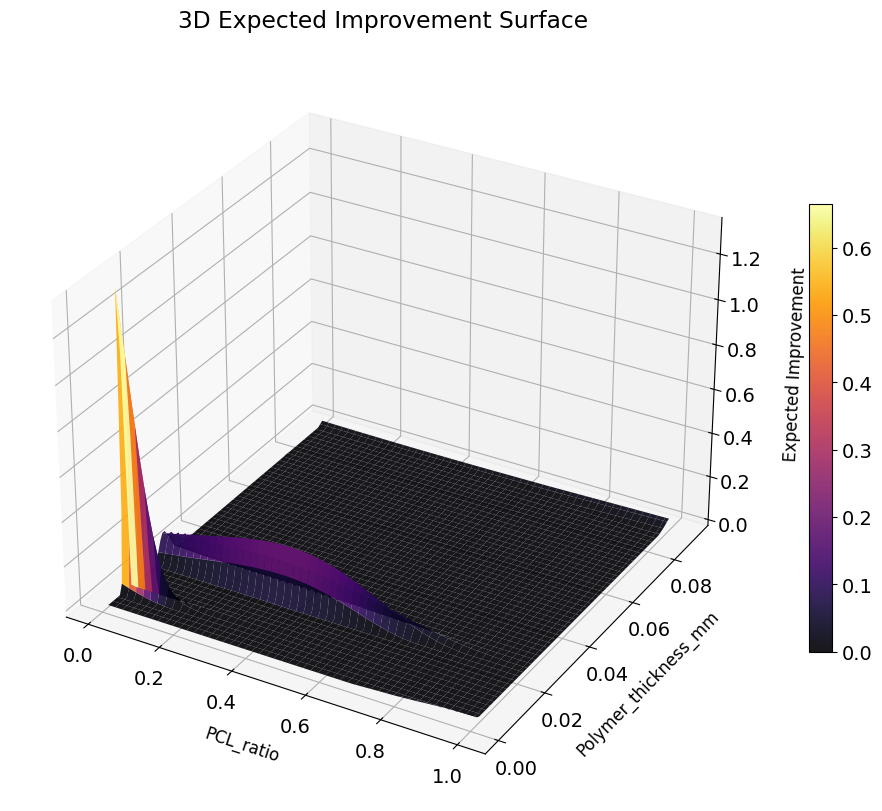

Saved: /content/GP_3D_EI_surface_7.5percent.png


In [14]:
df = df_7pt5
run_GP_and_Plot(df)